# Learning GNN-derived gene embeddings on PPI networks

This demo provides a pipeline for learning GNN-derived gene embeddings on CPDB network.

In [101]:
import os
import copy
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

import dgl
from dgl.dataloading import GraphDataLoader

import dataset, model
from train import FocalLoss
from train import (
    calculate_cluster_labels,
    visualize_embeddings_tsne,
    visualize_embeddings_pca,
    create_heatmap_with_stid,
    plot_cosine_similarity_matrix_for_clusters_with_values,
    draw_loss_plot,
    draw_f1_plot,
    draw_max_f1_plot
)


In [102]:
hyperparams = {
    "num_epochs": 20,
    "in_feats": 2,
    "out_feats": 128,
    "num_layers": 2,
    "num_heads": 2,
    "lr": 1e-3,
    "batch_size": 1,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

data_path = "data/emb"
plot = True

CLUSTER_COLORS = {
    0:  '#0077B6',  1:  '#0000FF',  2:  '#00B4D8',  3:  '#48EAC4',
    4:  '#F1C0E8',  5:  '#B9FBC0',  6:  '#32CD32',  7:  '#bee1e6',
    8:  '#8A2BE2',  9:  '#E377C2', 10: '#8EECF5', 11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700', 14: '#FF69B4', 15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50', 18: '#C71585', 19: '#20B2AA',
    20: '#48CAE4', 21: '#90DBF4', 22: '#0077B6', 23: '#00B4D8',
    24: '#6A5ACD', 25: '#66CDAA', 26: '#FF8C00', 27: '#9370DB'
}

In [103]:
num_epochs = hyperparams["num_epochs"]
in_feats = hyperparams["in_feats"]
out_feats = hyperparams["out_feats"]
num_layers = hyperparams["num_layers"]
num_heads = hyperparams["num_heads"]
learning_rate = hyperparams["lr"]
batch_size = hyperparams["batch_size"]
device = hyperparams["device"]

model_dir = os.path.join(data_path, "models")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir, f"model_dim{out_feats}_lay{num_layers}_epo{num_epochs}.pth"
)

ds = dataset.Dataset(data_path)
dl_train = GraphDataLoader([ds[0]], batch_size=batch_size, shuffle=True)
dl_valid = GraphDataLoader([ds[1]], batch_size=batch_size, shuffle=False)


In [104]:
net = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
).to(device)

best_model = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
)

optimizer = optim.Adam(net.parameters(), lr=learning_rate)

criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction="mean")
weight = torch.tensor([0.00001, 0.99999]).to(device)


In [105]:
results_path = "results/multiomics_meth/node_embeddings/"
os.makedirs(results_path, exist_ok=True)

all_embeddings, cluster_labels = calculate_cluster_labels(
    best_model, dl_train, device
)
all_embeddings = all_embeddings.reshape(
    all_embeddings.shape[0], -1
)


In [106]:
for graph, _ in dl_train:
    node_emb = best_model.get_node_embeddings(graph).detach().cpu().numpy()

    nx_graph = pickle.load(open(os.path.join(data_path, "raw/emb_train.pkl"), "rb"))
    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    stid_embeddings = {
        nx_graph.nodes[n]["stId"]: node_emb[node_to_index[n]]
        for n in nx_graph.nodes if "stId" in nx_graph.nodes[n]
    }

    pd.DataFrame.from_dict(stid_embeddings, orient="index").to_csv(
        f"data/multiomics_meth/ppi_embeddings_lr{learning_rate}_dim{out_feats}.csv",
        index_label="stId"
    )

    break


In [107]:
loss_per_epoch_train, loss_per_epoch_valid = [], []
f1_per_epoch_train, f1_per_epoch_valid = [], []
max_f1_scores_train, max_f1_scores_valid = [], []

best_valid_loss = float("inf")

with tqdm(total=num_epochs, desc="Training", unit="epoch") as pbar:
    for epoch in range(num_epochs):
        net.train()
        losses, f1s = [], []

        for graph, _ in dl_train:
            logits = net(graph)
            labels = graph.ndata["significance"].unsqueeze(-1)

            loss = criterion(logits, labels)
            preds = (logits.sigmoid() > 0.5).int()
            f1 = metrics.f1_score(labels.squeeze(1).int(), preds)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            f1s.append(f1)

        loss_per_epoch_train.append(np.mean(losses))
        f1_per_epoch_train.append(np.mean(f1s))

        pbar.update(1)


Training: 100%|██████████| 20/20 [00:09<00:00,  2.06epoch/s]


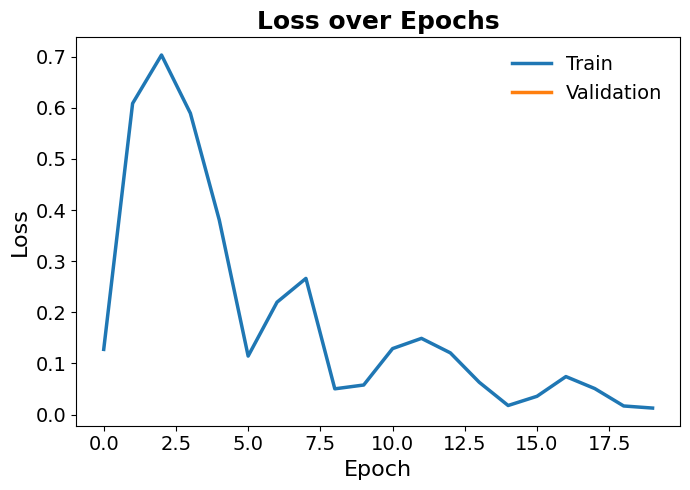

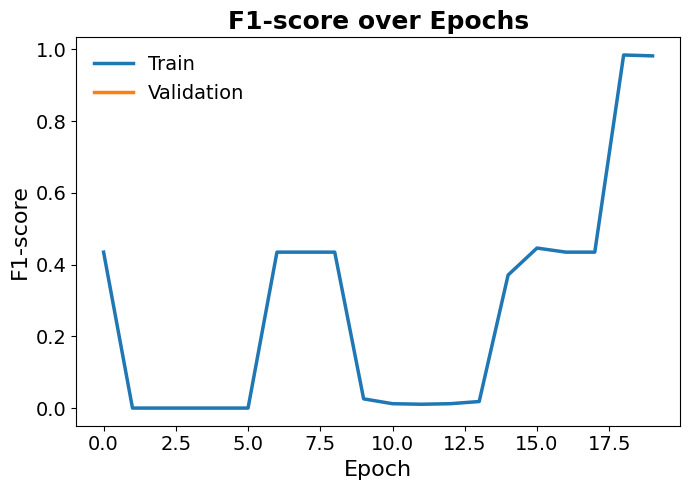

In [108]:
draw_loss_plot(
    loss_per_epoch_train,
    loss_per_epoch_valid,
    os.path.join(results_path, "loss.png")
)

draw_f1_plot(
    f1_per_epoch_train,
    f1_per_epoch_valid,
    os.path.join(results_path, "f1.png")
)


In [109]:
first_node_stId_in_cluster_initial = {}
first_node_embedding_in_cluster_initial = {}

for data in dl_train:
    graph, _ = data
    node_embeddings_initial = (
        best_model.get_node_embeddings(graph)
        .detach().cpu().numpy()
    )

    nx_graph = pickle.load(
        open(os.path.join(data_path, "raw/emb_train.pkl"), "rb")
    )

    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    for node, cluster in zip(nx_graph.nodes, cluster_labels):
        if "stId" not in nx_graph.nodes[node]:
            continue

        if cluster not in first_node_stId_in_cluster:
            first_node_stId_in_cluster[cluster] = nx_graph.nodes[node]["stId"]
            first_node_embedding_in_cluster_initial[cluster] = \
                node_embeddings_initial[node_to_index[node]]

    break


In [110]:

all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(best_model, dl_train, device)
all_embeddings_initial = all_embeddings_initial.reshape(all_embeddings_initial.shape[0], -1)  # Flatten 
save_path_heatmap_initial= os.path.join(results_path, f'ppi_embeddings_heatmap_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_matrix_initial= os.path.join(results_path, f'ppi_embeddings_matrix_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_pca_initial = os.path.join(results_path, f'ppi_embeddings_pca_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_t_SNE_initial = os.path.join(results_path, f'ppi_embeddings_t-SNE_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')


first_node_stId_in_cluster_initial-------------------------------
 {3: '1433B', 11: '2A5A', 14: 'A0A590TQL1', 4: 'ABCF1', 8: 'ACTN2', 15: 'ANK3', 1: 'ASPH', 10: 'BIRC3', 16: 'BUB1B', 5: 'CDN1B', 12: 'COQ8A', 17: 'CTND2', 0: 'ETFR1', 19: 'FHL2', 6: 'HNRH3', 9: 'KRA56', 13: 'MED15', 2: 'PIHD1', 7: 'PLIN1', 18: 'SLU7'}


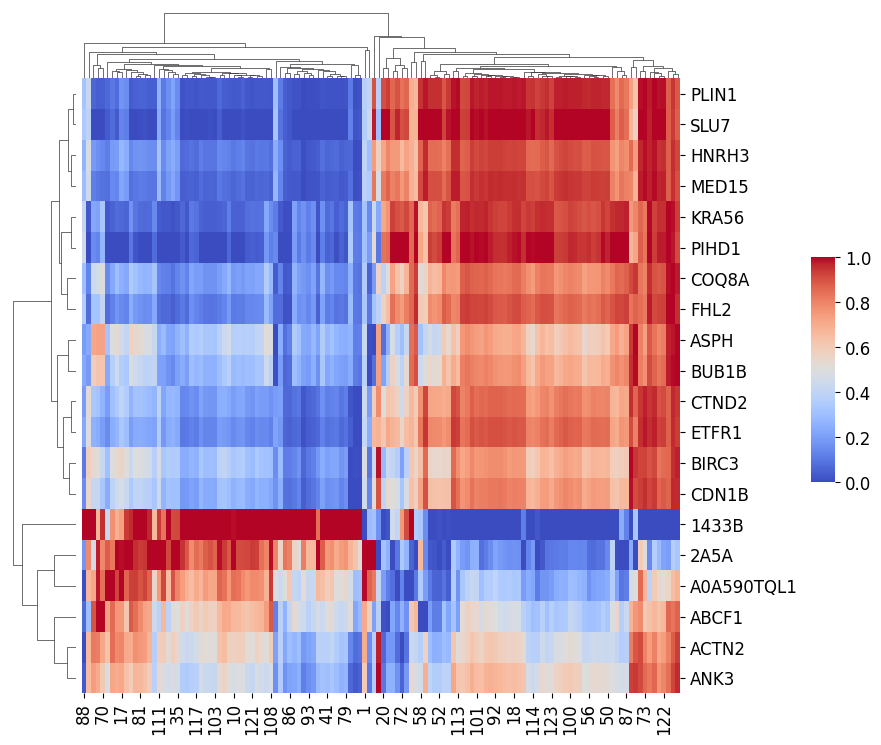

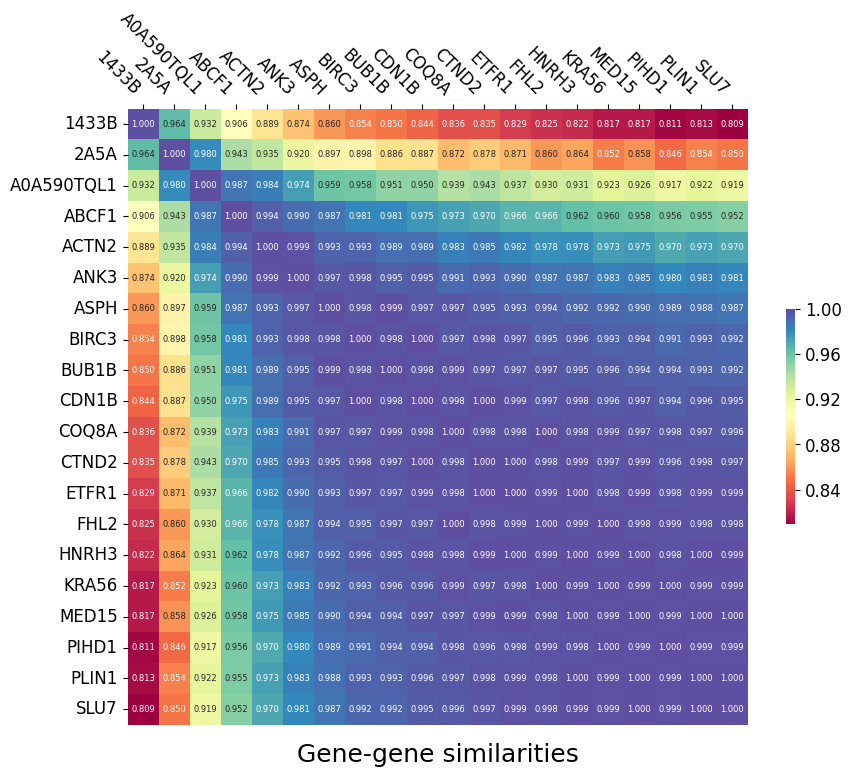

In [111]:
    for data in dl_train:
        graph, _ = data
        node_embeddings_initial= best_model.get_node_embeddings(graph).detach().cpu().numpy()
        graph_path = os.path.join(data_path, 'raw/emb_train.pkl')
        nx_graph = pickle.load(open(graph_path, 'rb'))

        assert len(cluster_labels_initial) == len(nx_graph.nodes), "Cluster labels and number of nodes must match"
        node_to_index_initial = {node: idx for idx, node in enumerate(nx_graph.nodes)}
        first_node_stId_in_cluster_initial= {}
        first_node_embedding_in_cluster_initial= {}

        stid_dic_initial= {}

        # Populate stid_dic with node stIds mapped to embeddings
        for node in nx_graph.nodes:
            if 'stId' in nx_graph.nodes[node]:
                stId = nx_graph.nodes[node]['stId']
                stid_dic_initial[nx_graph.nodes[node]['stId']] = node_embeddings_initial[node_to_index_initial[node]]

        # Convert stid_dic_initial to a DataFrame
        stid_df_initial = pd.DataFrame.from_dict(stid_dic_initial, orient='index')

        # Save to CSV
        ##csv_save_path = 'data/gene_embeddings_initial_sage.csv'
        csv_save_path_initial = os.path.join('data/multiomics_meth/', f'ppi_embeddings_lr{learning_rate}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.csv')
        ##csv_save_path_initial = os.path.join('data/', f'inhibition_gene_embeddings_lr{learning_rate}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.csv')
        stid_df_initial.to_csv(csv_save_path_initial, index_label='stId')
                
        ##print('stid_dic_initial=======================\n',stid_dic_initial) 
           
        for node, cluster in zip(nx_graph.nodes, cluster_labels_initial):
            if 'stId' in nx_graph.nodes[node]:
                if cluster not in first_node_stId_in_cluster_initial:
                    first_node_stId_in_cluster_initial[cluster] = nx_graph.nodes[node]['stId']
                    first_node_embedding_in_cluster_initial[cluster] = node_embeddings_initial[node_to_index_initial[node]]

        print('first_node_stId_in_cluster_initial-------------------------------\n', first_node_stId_in_cluster_initial)
        stid_list = list(first_node_stId_in_cluster_initial.values())
        embedding_list_initial = list(first_node_embedding_in_cluster_initial.values())
        create_heatmap_with_stid(embedding_list_initial, stid_list, save_path_heatmap_initial)
        plot_cosine_similarity_matrix_for_clusters_with_values(embedding_list_initial, stid_list, save_path_matrix_initial)

        break

In [112]:
def plot_embedding_with_cluster_legend(
    embeddings_2d,
    cluster_labels,
    cluster_to_stid,
    xlabel,
    ylabel,
    save_path
):
    plt.figure(figsize=(10, 8))

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]

        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=12,
            color=CLUSTER_COLORS[int(cluster_id)],  # fixed cluster color
            alpha=0.85,
            label=cluster_to_stid.get(cluster_id, f"Cluster {cluster_id}")
        )

    # ---- Styling ----
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.legend(
        title="Label",
        title_fontsize=14,
        fontsize=12,
        markerscale=2.2,
        bbox_to_anchor=(1.02, 0.5),  # vertically centered
        loc="center left",
        frameon=False
    )

    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()




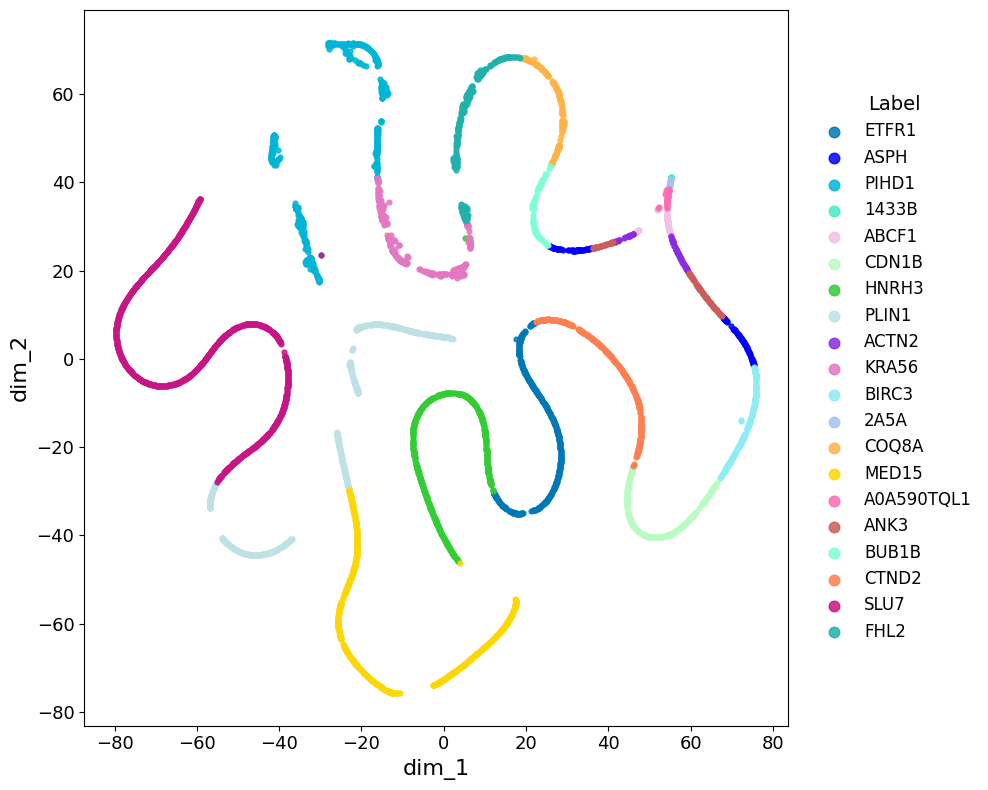

In [113]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

embeddings_tsne = tsne.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_tsne,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    # title="T-SNE of Embeddings",
    xlabel="dim_1",
    ylabel="dim_2",
    save_path=save_path_t_SNE_initial
)


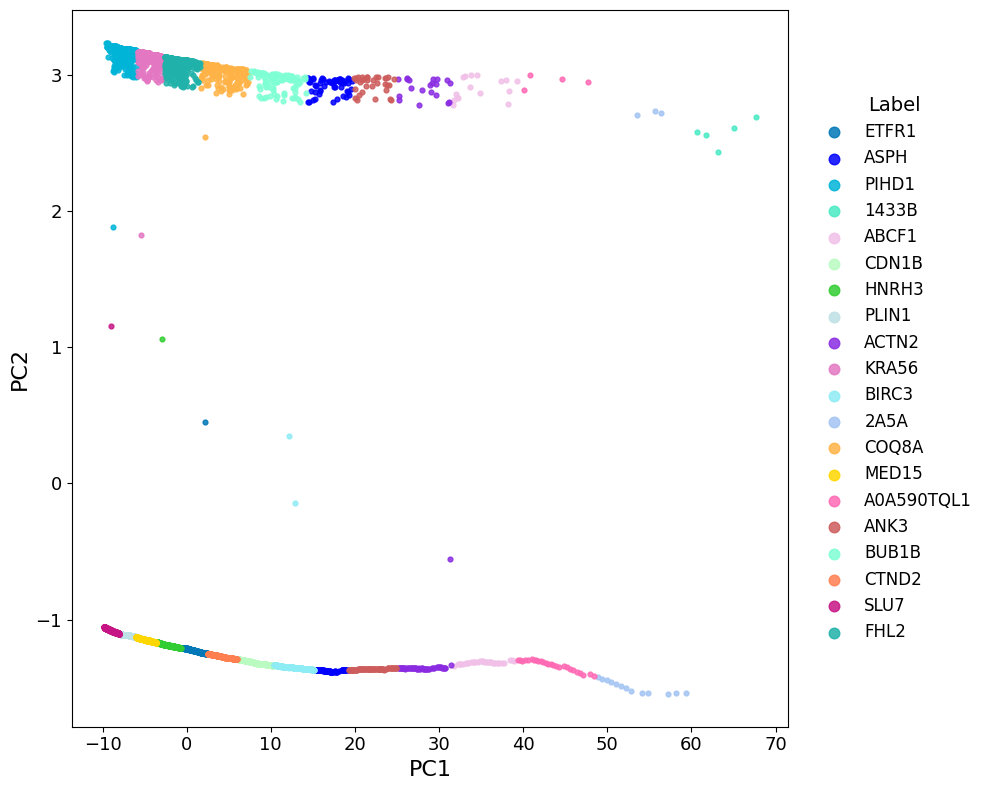

In [114]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_pca,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    # title="PCA of Embeddings",
    xlabel="PC1",
    ylabel="PC2",
    save_path=save_path_pca_initial
)


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


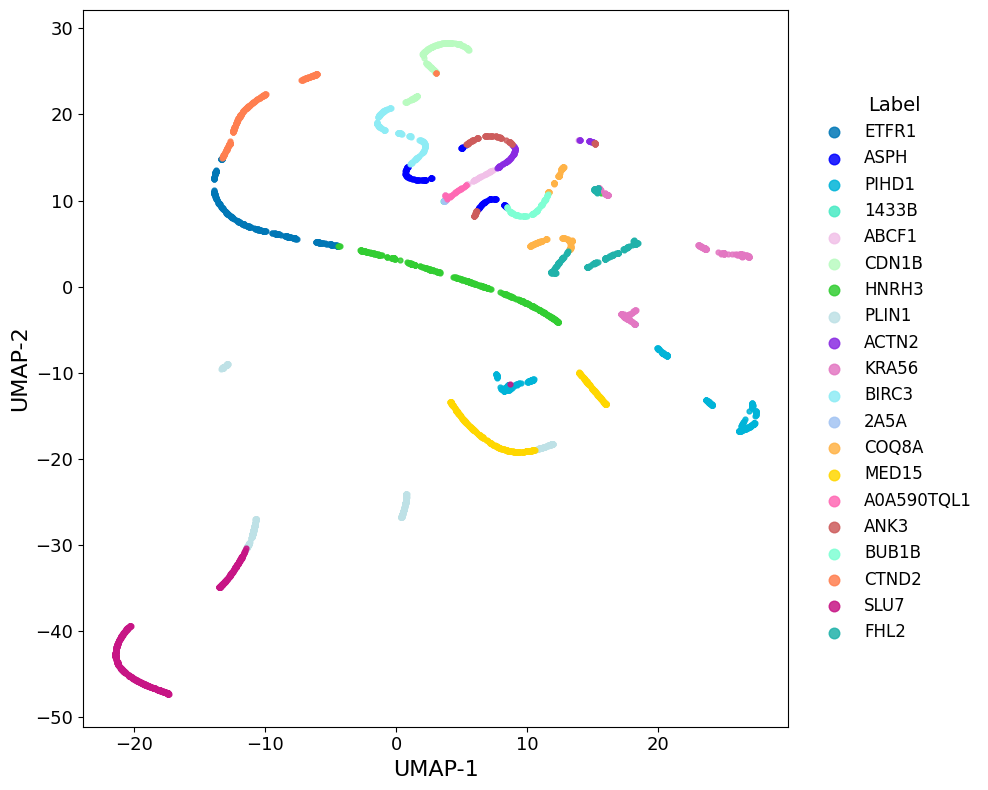

In [115]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_umap,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    # title="UMAP of Embeddings",
    xlabel="UMAP-1",
    ylabel="UMAP-2",
    save_path=os.path.join(results_path, "ppi_embeddings_umap_initial.png")
)


In [116]:
def annotate_cluster_centroids(embeddings_2d, cluster_labels, cluster_to_stid):
    """
    Annotate each cluster using the centroid of its points.

    embeddings_2d : np.ndarray (N, 2)
    cluster_labels : np.ndarray (N,)
    cluster_to_stid : dict {cluster_id: stId}
    """
    for cluster_id, stid in cluster_to_stid.items():
        idx = np.where(cluster_labels == cluster_id)[0]
        if len(idx) == 0:
            continue

        centroid = embeddings_2d[idx].mean(axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            stid,
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )



In [117]:
# stid_list = [
#     first_node_stId_in_cluster_initial[c]
#     for c in sorted(first_node_stId_in_cluster_initial)
# ]

# embedding_list = [
#     first_node_embedding_in_cluster_initial[c]
#     for c in sorted(first_node_embedding_in_cluster_initial)
# ]

# create_heatmap_with_stid(
#     embedding_list,
#     stid_list,
#     save_path_heatmap_initial
# )

# plot_cosine_similarity_matrix_for_clusters_with_values(
#     embedding_list,
#     stid_list,
#     save_path_matrix_initial
# )


In [118]:
all_embeddings, cluster_labels = calculate_cluster_labels(best_model, dl_train, device)
all_embeddings = all_embeddings.reshape(all_embeddings.shape[0], -1)  # Flatten 
save_path_heatmap= os.path.join(results_path, f'ppi_embeddings_heatmap_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
save_path_matrix= os.path.join(results_path, f'ppi_embeddings_matrix_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
save_path_pca = os.path.join(results_path, f'ppi_embeddings_pca_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
save_path_t_SNE = os.path.join(results_path, f'ppi_embeddings_t-SNE_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')


Training:   5%|▌         | 1/20 [00:00<00:18,  1.05epoch/s]

Best F1 Validation Score: 0.04572564612326044
Epoch 1 - F1 Train: 0.05803571428571429, F1 Valid: 0.04572564612326044


Training:  10%|█         | 2/20 [00:01<00:16,  1.09epoch/s]

Epoch 2 - F1 Train: 0.015209125475285171, F1 Valid: 0.02014098690835851


Training:  15%|█▌        | 3/20 [00:02<00:14,  1.15epoch/s]

...

Training:  90%|█████████ | 18/20 [00:14<00:01,  1.15epoch/s]

Epoch 18 - F1 Train: 0.9988518943742825, F1 Valid: 0.9994916115912558


Training:  95%|█████████▌| 19/20 [00:15<00:00,  1.12epoch/s]

Epoch 19 - F1 Train: 0.9996170049789352, F1 Valid: 1.0


Epoch 20 - F1 Train: 0.9996170049789352, F1 Valid: 1.0


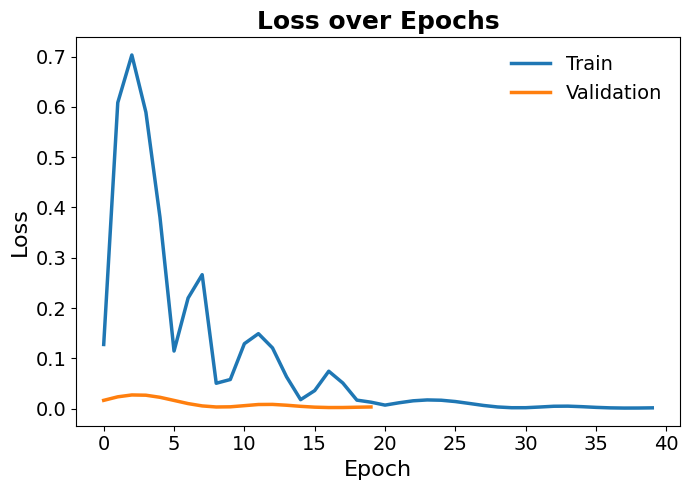

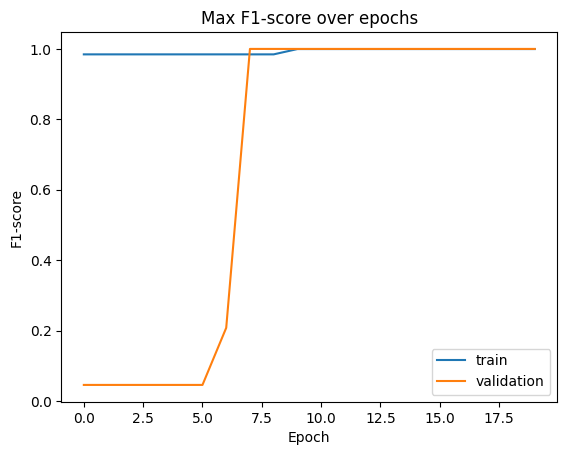

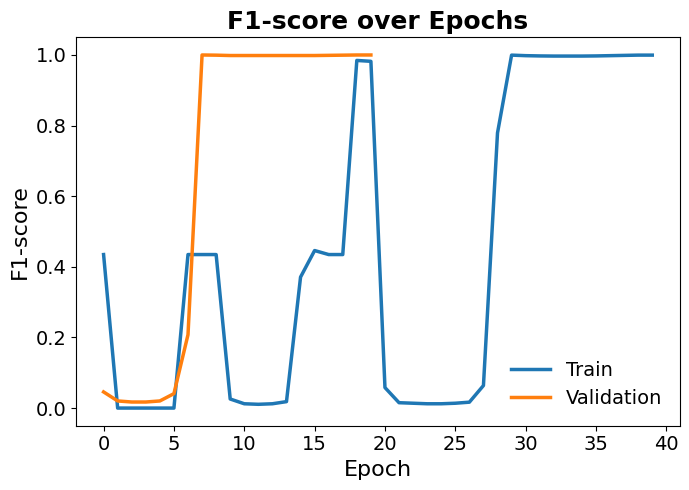

{11: '1433B', 2: '3MG', 15: 'ABCF1', 9: 'ABEC1', 6: 'AF9', 10: 'ANC2', 4: 'ARF1', 1: 'BIN1', 17: 'BKRB1', 8: 'CDN1B', 12: 'COA3', 19: 'CTIP', 18: 'ERCC5', 7: 'FBN1', 0: 'HDAC7', 16: 'KIF5A', 13: 'LMNB2', 5: 'ODPAT', 3: 'PGBM', 14: 'RUFY1'}


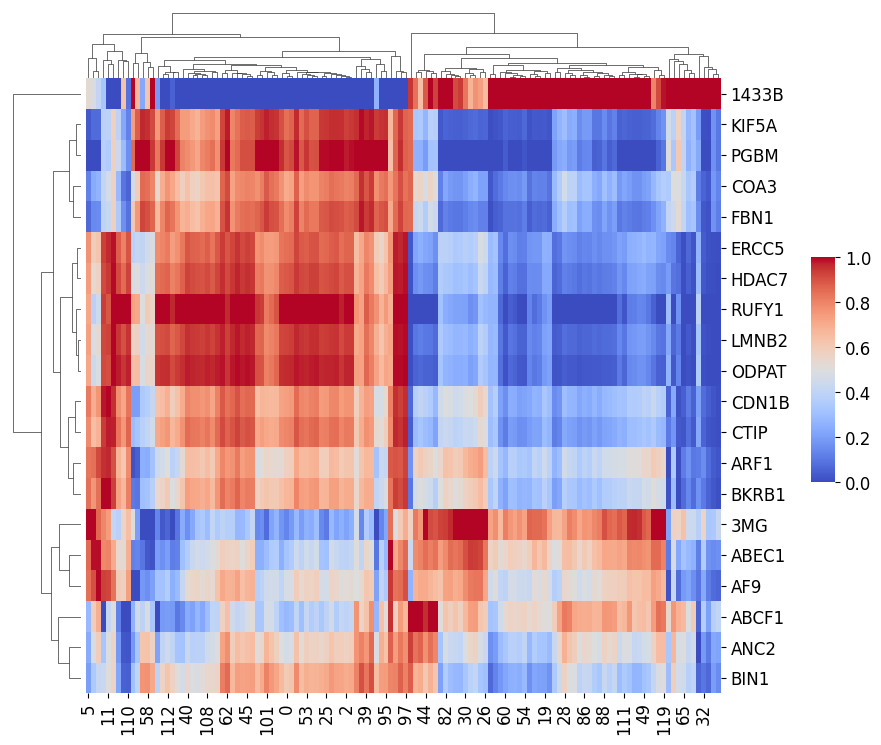

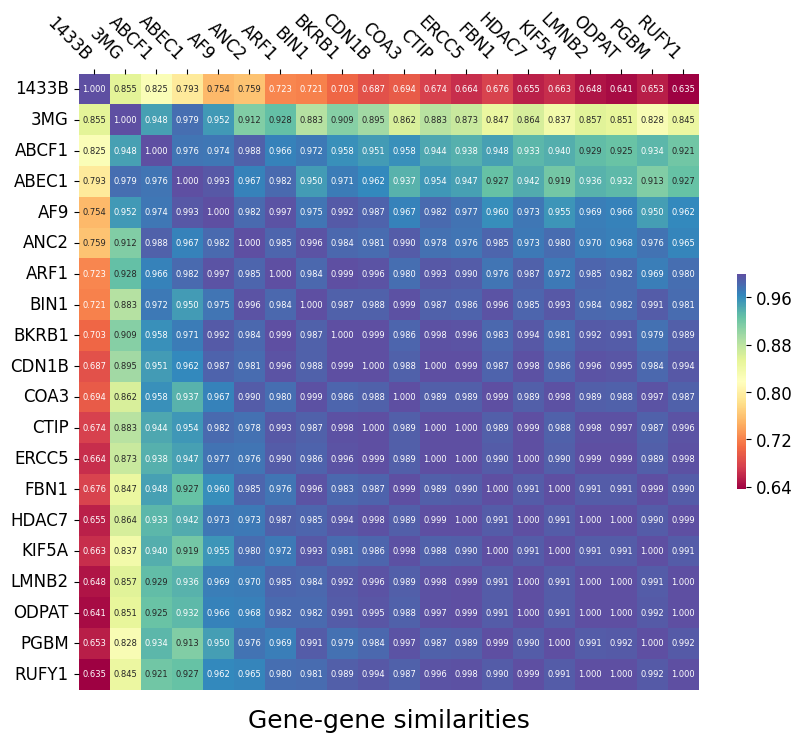

In [119]:

                
    # Start training  
    with tqdm(total=num_epochs, desc="Training", unit="epoch", leave=False) as pbar:
        for epoch in range(num_epochs):
            loss_per_graph = []
            f1_per_graph = [] 
            net.train()
            for data in dl_train:
                graph, name = data
                name = name[0]
                logits = net(graph)
                labels = graph.ndata['significance'].unsqueeze(-1)
                weight_ = weight[labels.data.view(-1).long()].view_as(labels)

                loss = criterion(logits, labels)
                loss_weighted = loss * weight_
                loss_weighted = loss_weighted.mean()

                # Update parameters
                optimizer.zero_grad()
                loss_weighted.backward()
                optimizer.step()
                
                # Append output metrics
                loss_per_graph.append(loss_weighted.item())
                ##preds = (logits.sigmoid() > 0.5).squeeze(1).int()
                preds = (logits.sigmoid() > 0.5).int()
                labels = labels.squeeze(1).int()
                f1 = metrics.f1_score(labels, preds)
                f1_per_graph.append(f1)

            running_loss = np.array(loss_per_graph).mean()
            running_f1_train = np.array(f1_per_graph).mean()
            loss_per_epoch_train.append(running_loss)
            f1_per_epoch_train.append(running_f1_train)

            # Validation iteration
            with torch.no_grad():
                loss_per_graph = []
                f1_per_graph = []
                net.eval()
                for data in dl_valid:
                    graph, name = data
                    name = name[0]
                    logits = net(graph)
                    labels = graph.ndata['significance'].unsqueeze(-1)
                    weight_ = weight[labels.data.view(-1).long()].view_as(labels)
                    loss = criterion(logits, labels)
                    loss_weighted = loss * weight_
                    loss_weighted = loss_weighted.mean()
                    loss_per_graph.append(loss_weighted.item())
                    ##preds = (logits.sigmoid() > 0.5).squeeze(1).int()
                    preds = (logits.sigmoid() > 0.5).int()
                    labels = labels.squeeze(1).int()
                    f1 = metrics.f1_score(labels, preds)
                    f1_per_graph.append(f1)

                running_loss = np.array(loss_per_graph).mean()
                running_f1_val = np.array(f1_per_graph).mean()
                loss_per_epoch_valid.append(running_loss)
                f1_per_epoch_valid.append(running_f1_val)
                
                max_f1_train = max(f1_per_epoch_train)
                max_f1_valid = max(f1_per_epoch_valid)
                max_f1_scores_train.append(max_f1_train)
                max_f1_scores_valid.append(max_f1_valid)

                if running_loss < best_valid_loss:
                    best_train_loss = running_loss
                    best_valid_loss = running_loss
                    best_f1_score = running_f1_val
                    best_model.load_state_dict(copy.deepcopy(net.state_dict()))
                    print(f"Best F1 Validation Score: {best_f1_score}")

            pbar.update(1)
            print(f"Epoch {epoch + 1} - F1 Train: {running_f1_train}, F1 Valid: {running_f1_val}")
            ## print(f"Epoch {epoch + 1} - Max F1 Train: {max_f1_train}, Max F1 Valid: {max_f1_valid}")

    all_embeddings, cluster_labels = calculate_cluster_labels(best_model, dl_train, device)
    all_embeddings = all_embeddings.reshape(all_embeddings.shape[0], -1)  # Flatten 
    ##print('cluster_labels=========================\n', cluster_labels)

    cos_sim = np.dot(all_embeddings, all_embeddings.T)
    norms = np.linalg.norm(all_embeddings, axis=1)
    cos_sim /= np.outer(norms, norms)

    if plot:
        loss_path = os.path.join(results_path, f'ppi_embeddings_loss_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
        f1_path = os.path.join(results_path, f'ppi_embeddings_f1_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
        max_f1_path = os.path.join(results_path, f'ppi_embeddings_max_f1_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
        matrix_path = os.path.join(results_path, f'ppi_embeddings_matrix_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
 
        draw_loss_plot(loss_per_epoch_train, loss_per_epoch_valid, loss_path)
        draw_max_f1_plot(max_f1_scores_train, max_f1_scores_valid, max_f1_path)
        draw_f1_plot(f1_per_epoch_train, f1_per_epoch_valid, f1_path)

    torch.save(best_model.state_dict(), model_path)
        
    cluster_stId_dict = {}  # Dictionary to store clusters and corresponding stIds
    significant_stIds = []  # List to store significant stIds
    clusters_with_significant_stId = {}  # Dictionary to store clusters and corresponding significant stIds
    clusters_node_info = {}  # Dictionary to store node info for each cluster
    
    for data in dl_train:
        graph, _ = data
        node_embeddings = best_model.get_node_embeddings(graph).detach().cpu().numpy()
        graph_path = os.path.join(data_path, 'raw/emb_train.pkl')
        nx_graph = pickle.load(open(graph_path, 'rb'))

        assert len(cluster_labels) == len(nx_graph.nodes), "Cluster labels and number of nodes must match"
        node_to_index = {node: idx for idx, node in enumerate(nx_graph.nodes)}
        first_node_stId_in_cluster = {}
        first_node_embedding_in_cluster = {}

        stid_dic = {}

        # Populate stid_dic with node stIds mapped to embeddings
        for node in nx_graph.nodes:
            if 'stId' in nx_graph.nodes[node]:
                stid = nx_graph.nodes[node]['stId']
                stid_dic[nx_graph.nodes[node]['stId']] = node_embeddings[node_to_index[node]]
                # Check if the node's significance is 'significant' and add its stId to the list
                if graph.ndata['significance'][node_to_index[node]].item() == 'significant':
                    significant_stIds.append(nx_graph.nodes[node]['stId'])

        stid_df_final = pd.DataFrame.from_dict(stid_dic, orient='index')

        # Save to CSV
        ##csv_save_path = 'data/gene_embeddings_final_sage.csv'
        csv_save_path_final = os.path.join('data/multiomics_meth/', f'ppi_embeddings_lr{learning_rate}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_final.csv')
        stid_df_final.to_csv(csv_save_path_final, index_label='stId')
                   
        for node, cluster in zip(nx_graph.nodes, cluster_labels):
            if 'stId' in nx_graph.nodes[node]:
                stid = nx_graph.nodes[node]['stId']
                if cluster not in first_node_stId_in_cluster:
                    first_node_stId_in_cluster[cluster] = nx_graph.nodes[node]['stId']
                    first_node_embedding_in_cluster[cluster] = node_embeddings[node_to_index[node]]
                    
                # Populate cluster_stId_dict
                if cluster not in cluster_stId_dict:
                    cluster_stId_dict[cluster] = []
                cluster_stId_dict[cluster].append(nx_graph.nodes[node]['stId'])

                # Populate clusters_with_significant_stId
                if cluster not in clusters_with_significant_stId:
                    clusters_with_significant_stId[cluster] = []
                if nx_graph.nodes[node]['stId'] in significant_stIds:
                    clusters_with_significant_stId[cluster].append(nx_graph.nodes[node]['stId'])
                
                # Populate clusters_node_info with node information for each cluster
                if cluster not in clusters_node_info:
                    clusters_node_info[cluster] = []
                node_info = {
                    'stId': nx_graph.nodes[node]['stId'],
                    'significance': graph.ndata['significance'][node_to_index[node]].item(),
                    'other_info': nx_graph.nodes[node]  # Add other relevant info if necessary
                }
                clusters_node_info[cluster].append(node_info)
            
        print(first_node_stId_in_cluster)
        stid_list = list(first_node_stId_in_cluster.values())
        embedding_list = list(first_node_embedding_in_cluster.values())
        heatmap_data = pd.DataFrame(embedding_list, index=stid_list)
        create_heatmap_with_stid(embedding_list, stid_list, save_path_heatmap)
        # Call the function to plot cosine similarity matrix for cluster representatives with similarity values
        plot_cosine_similarity_matrix_for_clusters_with_values(embedding_list, stid_list, save_path_matrix)

        break


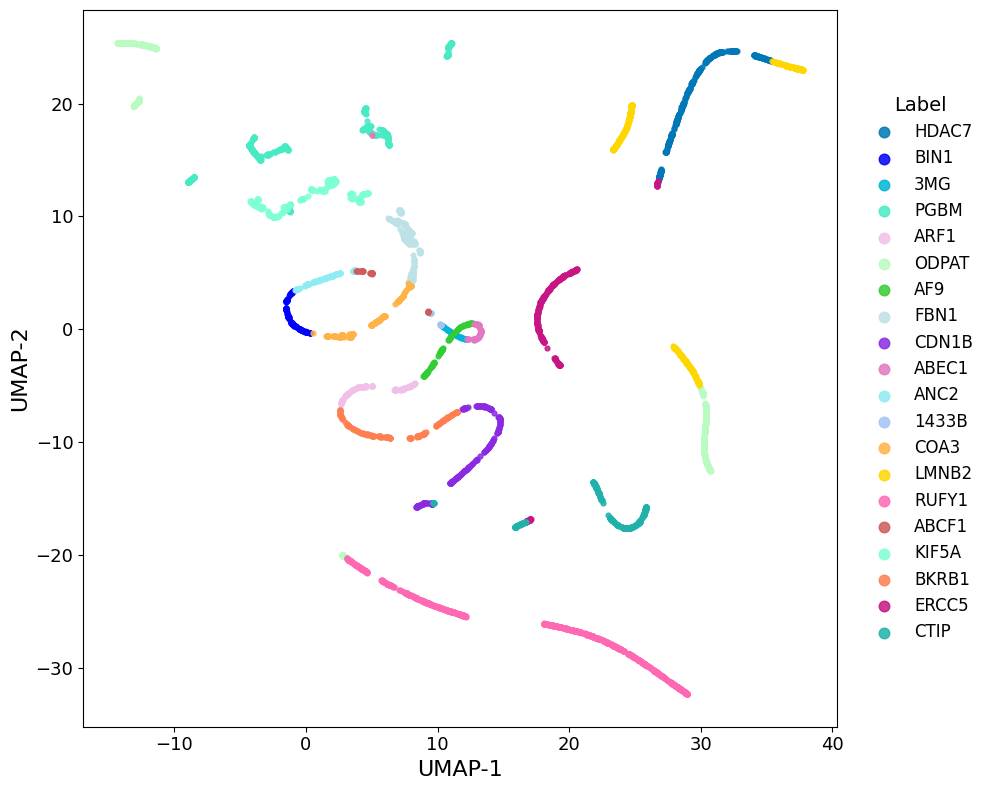

In [120]:
embeddings_umap = umap_model.fit_transform(all_embeddings)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_umap,
    cluster_labels=cluster_labels,
    cluster_to_stid=first_node_stId_in_cluster,
    # title="UMAP of Embeddings",
    xlabel="UMAP-1",
    ylabel="UMAP-2",
    save_path=os.path.join(results_path, "ppi_embeddings_umap.png")
)